# Análisis Exploratorio de Datos — Mantenimiento Predictivo Industrial
## Dataset AI4I 2020 | UCI Machine Learning Repository

**Autor:** Felipe Bojorque  
**Máster:** Data Science & AI  
**Descripción:** EDA del dataset AI4I 2020 para identificar patrones operativos que preceden a fallos de maquinaria industrial. Este análisis responde cinco preguntas analíticas concretas.

**Preguntas analíticas:**
1. ¿Cuál es la distribución de los 5 tipos de fallo y qué tipo domina?
2. ¿Bajo qué rangos de temperatura se concentran los fallos térmicos (HDF)?
3. ¿Existe una zona de peligro en el espacio torque × velocidad?
4. ¿El desgaste acumulado de herramienta predice el tipo de fallo TWF?
5. ¿El tipo de producto (L/M/H) tiene diferente tasa de fallos?

---

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# Configración de rutas
cwd = Path().resolve()
ROOT = cwd if (cwd / "src").exists() else cwd.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from loguru import logger

from src.io import load_parquet
from src.config import FAILURE_TYPES, NUMERIC_COLS
from src.viz import (
    plot_failure_distribution,
    plot_correlation_heatmap,
    plot_torque_speed_scatter,
    plot_temp_delta_by_failure,
    plot_wear_by_product_type,
    plot_failure_rate_by_type,
    plot_wear_vs_twf,
)

logger.info("Setup completado — ROOT: {}", ROOT)

2026-05-06 16:31:07.202 | INFO     | __main__:<module>:28 - Setup completado — ROOT: /home/felipebojorquem/master_dataScience/predictive_maintenance_eda


---

## 1. Carga del dataset procesado

Se carga desde Parquet generado por main.py. El dataset ya pasó por clean(), validate_schema() y build_features(). Las columnas UDI y Product ID han sido eliminadas y se han añadido tres features: temp_delta, power_W y wear_rate.

In [3]:
df = load_parquet()

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

2026-05-06 16:31:07.248 | INFO     | src.io:load_parquet:47 - Cargando dataset procesado desde /home/felipebojorquem/master_dataScience/predictive_maintenance_eda/data/processed/ai4i2020_clean.parquet


Shape: (10000, 15)
Columnas: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'temp_delta', 'power_W', 'wear_rate']


In [4]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_delta,power_W,wear_rate
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0.000000
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,0.000439
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,0.000645
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,0.001181
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,0.001526


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Type                     10000 non-null  category
 1   Air temperature [K]      10000 non-null  float64 
 2   Process temperature [K]  10000 non-null  float64 
 3   Rotational speed [rpm]   10000 non-null  int64   
 4   Torque [Nm]              10000 non-null  float64 
 5   Tool wear [min]          10000 non-null  int64   
 6   Machine failure          10000 non-null  int64   
 7   TWF                      10000 non-null  int64   
 8   HDF                      10000 non-null  int64   
 9   PWF                      10000 non-null  int64   
 10  OSF                      10000 non-null  int64   
 11  RNF                      10000 non-null  int64   
 12  temp_delta               10000 non-null  float64 
 13  power_W                  10000 non-null  float64 
 14  wear_ra

In [6]:
df.describe().round(3)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_delta,power_W,wear_rate
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,300.005,310.006,1538.776,39.987,107.951,0.034,0.005,0.012,0.010,0.010,0.002,10.001,6279.745,0.018
std,2.000,1.484,179.284,9.969,63.654,0.181,0.068,0.107,0.097,0.099,0.044,1.001,1067.418,0.011
min,295.300,305.700,1168.000,3.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7.600,1148.441,0.000
25%,298.300,308.800,1423.000,33.200,53.000,0.000,0.000,0.000,0.000,0.000,0.000,9.300,5561.184,0.008
50%,300.100,310.100,1503.000,40.100,108.000,0.000,0.000,0.000,0.000,0.000,0.000,9.800,6271.027,0.017
75%,301.500,311.100,1612.000,46.800,162.000,0.000,0.000,0.000,0.000,0.000,0.000,11.000,7003.003,0.026
max,304.500,313.800,2886.000,76.600,253.000,1.000,1.000,1.000,1.000,1.000,1.000,12.100,10469.923,0.128


**Observaciones de la inspección inicial:**
- 10.000 registros sin valores nulos (validado por pandera en el pipeline).
- La variable target Machine failure tiene una tasa de desbalanceo visible en la media, se cuantificará en la sección siguiente.
- Las tres features (temp_delta, power_W, wear_rate) están disponibles para el análisis.
- El rango de Rotational speed [rpm] y Torque [Nm] sugiere una distribución con cola derecha, a examinar en la Pregunta 3.

---

## 2. Visión general del target y los fallos

Antes de entrar en las preguntas analíticas, se cuantifica el desbalanceo de clase y la coocurrencia de los tipos de fallo.

In [7]:
# Tasa global de fallos
total = len(df)
n_failures = df["Machine failure"].sum()
failure_rate = n_failures / total * 100

print(f"Total de registros   : {total:,}")
print(f"Registros con fallo  : {n_failures:,} ({failure_rate:.2f}%)")
print(f"Registros sin fallo  : {total - n_failures:,} ({100 - failure_rate:.2f}%)")
print()

# Conteo por tipo de fallo
failure_counts = df[FAILURE_TYPES].sum().sort_values(ascending=False)
print("Conteo por tipo de fallo:")
for ft, count in failure_counts.items():
    print(f"  {ft}: {count} ({count/total*100:.2f}%)")

Total de registros   : 10,000
Registros con fallo  : 339 (3.39%)
Registros sin fallo  : 9,661 (96.61%)

Conteo por tipo de fallo:
  HDF: 115 (1.15%)
  OSF: 98 (0.98%)
  PWF: 95 (0.95%)
  TWF: 46 (0.46%)
  RNF: 19 (0.19%)


---

## Pregunta 1 — ¿Cuál es la distribución de los 5 tipos de fallo y qué tipo domina?

El dataset recoge cinco mecanismos de fallo independientes. Comprender cuál domina en frecuencia determina qué variables predictoras priorizar en la fase de modelado.

In [8]:
fig1 = plot_failure_distribution(df)
fig1.show()

2026-05-06 16:31:07.647 | INFO     | src.viz:plot_failure_distribution:34 - Gráfico 1 generado: distribución de fallos


**Interpretación — Pregunta 1:**

El fallo más frecuente es **HDF** con **115** ocurrencias (**1.15%** del total de fallos), seguido de **OSF** con **98** (**0.98%**). El fallo menos frecuente es **RNF** (Random Failure), lo cual es consistente con su naturaleza estocástica — no está asociado a ningún mecanismo de degradación determinista, por lo que será descartado en la fase de modelado supervisado.

La dominancia de **Heat Disipation Failure HDF** tiene implicaciones directas en la selección de features: las variables candidatas a ser principales para el clasificador se analizaran en la siguiente sección.

> **Referencia:** Fig. 1 — plot_failure_distribution()

---

## Pregunta 2 — ¿Bajo qué condiciones térmicas se concentran los fallos HDF?

El fallo HDF (Heat Dissipation Failure) ocurre cuando el sistema no puede disipar el calor generado en el proceso. La feature temp_delta (diferencia entre temperatura de proceso y temperatura del aire) fue diseñada específicamente para discriminar este tipo de fallo: en condiciones normales la diferencia es estable (~10 K); desviaciones significativas indican estrés térmico.

In [9]:
# Estadísticas de temp_delta por grupo HDF
temp_stats = df.groupby("HDF")["temp_delta"].describe().round(3)
print("Estadísticas de temp_delta por HDF (0=normal, 1=fallo):")
print(temp_stats)

Estadísticas de temp_delta por HDF (0=normal, 1=fallo):
      count    mean    std  min  25%  50%   75%   max
HDF                                                  
0    9885.0  10.021  0.988  7.6  9.3  9.8  11.0  12.1
1     115.0   8.228  0.282  7.6  8.0  8.3   8.5   8.6


In [10]:
fig2 = plot_temp_delta_by_failure(df)
fig2.show()

2026-05-06 16:31:08.526 | INFO     | src.viz:plot_temp_delta_by_failure:60 - Gráfico 2 generado: boxplot delta térmico vs HDF


**Interpretación — Pregunta 2:**

Los fallos HDF se concentran en valores de temp_delta = 8.0–8.5 K, significativamente por debajo de la operación normal (9.3–11.0 K). 
La reducción del delta térmico indica que el aire circundante se calienta al fallar la disipación, comprimiendo la diferencia proceso-aire.
La separación entre grupos es clara y con varianza mínima en HDF, lo que sugiere un umbral de activación.temp_delta queda confirmada como feature candidata para el clasificador de HDF.

> **Referencia:** Fig. 2 — `plot_temp_delta_by_failure()`

---

## Pregunta 3 — ¿Existe una zona de peligro en el espacio torque × velocidad?

La potencia mecánica es el producto del torque por la velocidad angular. Operar en valores extremos de ambas variables simultáneamente sobrecarga la transmisión y puede provocar fallos por potencia (PWF) o sobrecarga (OSF). El scatter plot a continuación colorea cada punto según si hubo fallo o no.

In [11]:
# Estadísticas de power_W por fallo
power_stats = df.groupby("Machine failure")["power_W"].describe().round(1)
print("Estadísticas de power_W [W] por Machine failure:")
print(power_stats)

Estadísticas de power_W [W] por Machine failure:
                  count    mean     std     min     25%     50%     75%  \
Machine failure                                                           
0                9661.0  6244.5  1011.4  3515.0  5549.3  6243.0  6952.1   
1                 339.0  7282.8  1851.1  1148.4  6669.1  7611.4  8548.9   

                     max  
Machine failure           
0                 8998.0  
1                10469.9  


In [12]:
fig3 = plot_torque_speed_scatter(df)
fig3.show()

2026-05-06 16:31:08.594 | INFO     | src.viz:plot_torque_speed_scatter:84 - Gráfico 3 generado: scatter torque vs velocidad


**Interpretación — Pregunta 3:**

La zona de peligro principal se localiza en el rango **1.200–1.400 rpm con torque >60 Nm**, donde se concentra la mayoría de fallos. A baja velocidad con alto torque, la energía mecánica se disipa como calor en lugar de trabajo útil — condición de sobrecarga térmica y mecánica simultánea. La relación torque-velocidad sigue una curva hiperbólica consistente con operación a potencia nominal constante, validando la feature: power_W (P = τ × ω) como representación del régimen operativo. Se observa una segunda región de fallos a alta velocidad (>2.400 rpm, torque <15 Nm), posiblemente asociada a tipos de fallo distintos (OSF/PWF), lo que motiva un clasificador multiclase en la fase de modelado.

> **Referencia:** Fig. 3 — `plot_torque_speed_scatter()`

---

## Pregunta 4 — ¿El desgaste acumulado de herramienta predice el tipo de fallo TWF?

El fallo TWF (Tool Wear Failure) ocurre cuando la herramienta acumula suficiente desgaste para degradar la calidad del proceso. Si el desgaste es un predictor fiable, deberíamos observar una distribución claramente separada entre los grupos TWF=0 y TWF=1.

In [13]:
# Estadísticas de Tool wear por grupo TWF
wear_stats = df.groupby("TWF")["Tool wear [min]"].describe().round(1)
print("Estadísticas de Tool wear [min] por TWF (0=normal, 1=fallo):")
print(wear_stats)

Estadísticas de Tool wear [min] por TWF (0=normal, 1=fallo):
      count   mean   std    min    25%    50%    75%    max
TWF                                                        
0    9954.0  107.4  63.4    0.0   53.0  107.0  162.0  251.0
1      46.0  216.4  12.3  198.0  207.0  214.5  224.2  253.0


2026-05-06 16:31:08.737 | INFO     | src.viz:plot_wear_vs_twf:132 - Gráfico 4 generado: boxplot + ECDF desgaste vs TWF


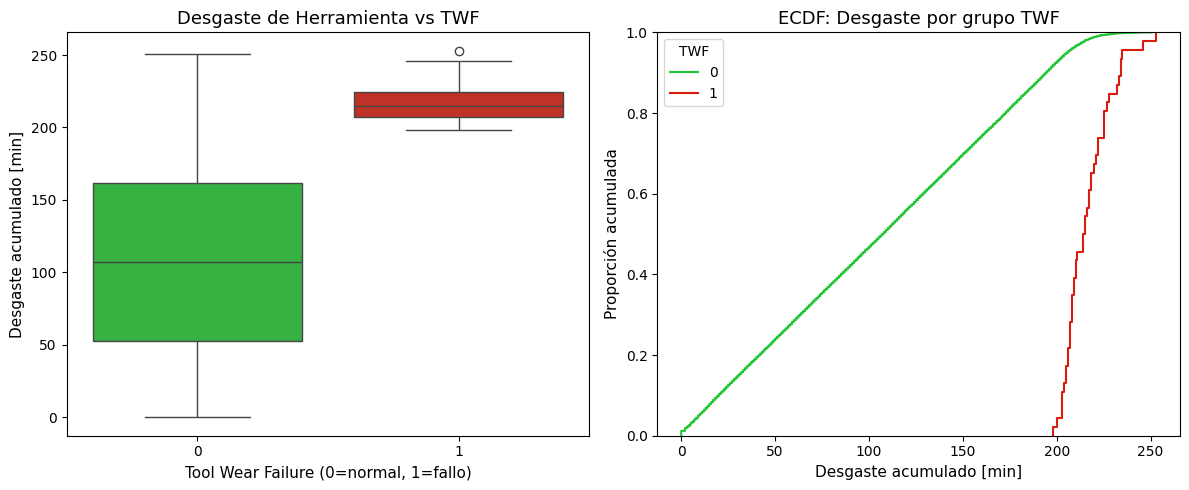

In [14]:
fig4 = plot_wear_vs_twf(df)
fig4.savefig(ROOT / "reports" / "fig4_wear_vs_twf.png", dpi=150, bbox_inches="tight")
display(fig4)
plt.close(fig4)

**Interpretación — Pregunta 4:**

El desgaste acumulado predice TWF con separación casi perfecta: el 100% de los fallos TWF ocurren con Tool wear > 200 min, mientras que el 90% de la operación normal se mantiene por debajo de ese umbral (ECDF, grupo 0). La mediana del grupo TWF=1 es 214.5 min con RIC <20 min, indicando un umbral de activación determinista más que una degradación gradual. De los 5 tipos de fallo, TWF es el más predecible con una sola variable — argumento directo para incluir Tool wear [min] como feature prioritaria en el clasificador.

> **Referencia:** Fig. 4 — plot_wear_vs_twf( )

---

## Pregunta 5 — ¿El tipo de producto (L/M/H) afecta la tasa de fallos?

El dataset incluye tres calidades de producto: L (Low), M (Medium) y H (High). La relación entre calidad y tasa de fallo no es trivial — productos de mayor calidad implican procesos más exigentes, pero productos de menor calidad pueden representar mayor volumen operativo.

In [15]:
# Distribución de tipo de producto
type_counts = df["Type"].value_counts()
print("Distribución de tipo de producto:")
print(type_counts)
print()

# Tasa de fallo por tipo
failure_by_type = df.groupby("Type", observed=True)["Machine failure"].agg(["sum", "count"])
failure_by_type["failure_rate_%"] = (failure_by_type["sum"] / failure_by_type["count"] * 100).round(2)
print("Tasa de fallo por tipo de producto:")
print(failure_by_type)

Distribución de tipo de producto:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Tasa de fallo por tipo de producto:
      sum  count  failure_rate_%
Type                            
H      21   1003            2.09
L     235   6000            3.92
M      83   2997            2.77


In [16]:
fig5a = plot_failure_rate_by_type(df)
fig5a.show()

2026-05-06 16:31:09.018 | INFO     | src.viz:plot_failure_rate_by_type:164 - Gráfico 5a generado: tasa de fallo por tipo


In [17]:
fig5b = plot_wear_by_product_type(df)
fig5b.show()

2026-05-06 16:31:09.061 | INFO     | src.viz:plot_wear_by_product_type:193 - Gráfico 5b generado: histograma desgaste por tipo


**Interpretación — Pregunta 5:**

La tasa de fallo decrece con la calidad del producto: L=3.92%, M=2.77%, H=2.09%. La distribución de desgaste normalizada por probabilidad muestra que los tres tipos operan con perfiles de desgaste prácticamente idénticos (distribución uniforme 0–210 min), descartando que L acumule más desgaste que H. La diferencia en tasa de fallo es intrínseca al tipo de producto — tolerancias operativas y condiciones de proceso — no un artefacto del tiempo de operación. Type tiene valor predictivo para el clasificador pero es independiente de Tool wear [min].

> **Referencia:** Fig. 5a — plot_failure_rate_by_type( ) | Fig. 5b — plot_wear_by_product_type( )

---

## 6. Análisis cruzado — tablas resumen

Síntesis cuantitativa que cruza las variables analizadas en las preguntas anteriores. Estas agregaciones respaldan las conclusiones de la sección siguiente y constituyen la base tabular del análisis exploratorio.

In [18]:
# Tabla 1: tasa de fallo por tipo de producto y tipo de fallo
pivot_type_failure = (
    df.groupby("Type", observed=True)[FAILURE_TYPES + ["Machine failure"]]
    .agg("sum")
    .assign(total=df.groupby("Type", observed=True).size())
)
pivot_type_failure["failure_rate_%"] = (
    pivot_type_failure["Machine failure"] / pivot_type_failure["total"] * 100
).round(2)

logger.info("Tabla 1: fallo × tipo de producto")
pivot_type_failure

2026-05-06 16:31:09.086 | INFO     | __main__:<module>:11 - Tabla 1: fallo × tipo de producto


,TWF,HDF,PWF,OSF,RNF,Machine failure,total,failure_rate_%
Type,,,,,,,,
H,7,8,5,2,4,21,1003,2.09
L,25,76,59,87,13,235,6000,3.92
M,14,31,31,9,2,83,2997,2.77


**Tabla 1 — Fallo × tipo de producto:**

El tipo L concentra el mayor volumen absoluto de fallos (235) por ser el más representado en el dataset (6.000 unidades), pero su tasa relativa (3.92%) es también la más alta. HDF y OSF dominan en los tres tipos. El tipo H presenta la menor tasa (2.09%) con predominio de HDF, consistente con procesos de mayor calidad que operan en condiciones térmicas más controladas.

In [20]:
# Tabla 2: tasa de fallo por bucket de desgaste acumulado
df["wear_bucket"] = pd.cut(
    df["Tool wear [min]"],
    bins=[0, 50, 100, 150, 200, 260],
    labels=["0–50", "51–100", "101–150", "151–200", "201–260"],
)

pivot_wear_failure = (
    df.groupby("wear_bucket", observed=True)[FAILURE_TYPES + ["Machine failure"]]
    .agg("sum")
    .assign(total=df.groupby("wear_bucket", observed=True).size())
)
pivot_wear_failure["failure_rate_%"] = (
    pivot_wear_failure["Machine failure"] / pivot_wear_failure["total"] * 100
).round(2)

logger.info("Tabla 2: fallo × buckets de desgaste")
pivot_wear_failure

2026-05-06 16:33:32.737 | INFO     | __main__:<module>:17 - Tabla 2: fallo × buckets de desgaste


,TWF,HDF,PWF,OSF,RNF,Machine failure,total,failure_rate_%
wear_bucket,,,,,,,,
0–50,0,26,21,0,4,49,2276,2.15
51–100,0,28,25,0,3,53,2271,2.33
101–150,0,27,22,0,3,50,2295,2.18
151–200,2,25,16,30,7,66,2276,2.90
201–260,44,9,8,68,2,118,762,15.49


**Tabla 2 — Fallo × buckets de desgaste:**

La tasa de fallo escala con el desgaste acumulado, alcanzando el 15.49% en el bucket 201–260 min. El bucket 201–260 concentra la totalidad de los fallos TWF (44) y la mayoría de OSF (68), confirmando el umbral determinista identificado en la Pregunta 4. Significativamente, HDF y PWF decrecen en ese mismo bucket (9 y 8 respectivamente frente a ~27 y ~23 en rangos intermedios): las máquinas que llegan a alto desgaste son aquellas que no fallaron antes por temperatura o potencia — efecto de supervivencia que confirma la independencia entre mecanismos de fallo térmico/eléctrico y desgaste mecánico acumulado.

In [23]:
# Tabla 3: tasa de fallo en el espacio torque × velocidad (bins)
df["rpm_bucket"] = pd.cut(
    df["Rotational speed [rpm]"],
    bins=[1100, 1400, 1700, 2000, 2400, 3000],
    labels=["1100–1400", "1401–1700", "1701–2000", "2001–2400", "2401–3000"],
)
df["torque_bucket"] = pd.cut(
    df["Torque [Nm]"],
    bins=[0, 20, 40, 60, 80],
    labels=["0–20", "21–40", "41–60", "61–80"],
)

pivot_torque_rpm = (
    df.groupby(["rpm_bucket", "torque_bucket"], observed=True)["Machine failure"]
    .agg(["sum", "count"])
    .assign(failure_rate=lambda x: (x["sum"] / x["count"] * 100).round(2))
    .rename(columns={"sum": "fallos", "count": "total"})
    .reset_index()
    .pivot(index="torque_bucket", columns="rpm_bucket", values="failure_rate")
    .fillna(0)
)

logger.info("Tabla 3: torque × velocidad × tasa de fallo")
pivot_torque_rpm

2026-05-06 16:47:32.299 | INFO     | __main__:<module>:23 - Tabla 3: torque × velocidad × tasa de fallo


rpm_bucket,1100–1400,1401–1700,1701–2000,2001–2400,2401–3000
torque_bucket,,,,,
0–20,0.00,0.00,4.35,3.05,60.87
21–40,0.00,0.61,0.55,0.00,0.00
41–60,9.06,0.95,0.00,0.00,0.00
61–80,40.09,71.43,0.00,0.00,0.00


**Tabla 3 — Torque × velocidad × tasa de fallo (%):**

Se identifican dos zonas de peligro operativas con tasas de fallo extremas. La zona principal es **1.401–1.700 rpm × 61–80 Nm** con una tasa del **71.4%**, seguida de **1.100–1.400 rpm × 61–80 Nm** con **40.1%**: ambas combinan torque máximo con velocidad baja-media, condición en la que la energía mecánica se
disipa como calor en lugar de trabajo útil. La segunda zona de riesgo es **2.401–3.000 rpm × 0–20 Nm** con **60.9%**: alta velocidad con torque mínimo implica operación fuera del rango nominal, asociada a OSF/PWF. La región central de la tabla (1.701–2.400 rpm × 21–60 Nm) presenta tasas por debajo del 1%, definiendo la **zona de operación segura** del sistema.

In [24]:
# Tabla 4: estadísticas de temperatura por tipo de fallo
temp_by_failure = pd.concat([
    df.groupby(ft)[["Air temperature [K]", "Process temperature [K]", "temp_delta"]]
    .agg(["mean", "std"])
    .round(3)
    .rename(index={0: "Normal", 1: "Fallo"})
    .assign(failure_type=ft)
    for ft in FAILURE_TYPES
])

logger.info("Tabla 4: temperatura × tipo de fallo")
temp_by_failure

2026-05-06 16:53:21.867 | INFO     | __main__:<module>:11 - Tabla 4: temperatura × tipo de fallo


Air temperature [K]        Process temperature [K]        temp_delta  \
                      mean    std                    mean    std       mean   
Normal             300.004  2.001                 310.005  1.484     10.001   
Fallo              300.298  1.946                 310.165  1.484      9.867   
Normal             299.975  1.992                 309.996  1.488     10.021   
Fallo              302.561  0.602                 310.789  0.645      8.228   
Normal             300.004  1.999                 310.006  1.483     10.002   
Fallo              300.076  2.147                 309.955  1.600      9.879   
Normal             300.005  2.000                 310.005  1.484     10.000   
Fallo              300.045  2.029                 310.073  1.511     10.029   
Normal             300.003  2.001                 310.004  1.483     10.001   
Fallo              300.816  1.708                 310.763  1.460      9.947   

              failure_type  
          std               
Normal  1.001          TWF  
Fallo   1.058          TWF  
Normal  0.988          HDF  
Fallo   0.282          HDF  
Normal  1.001          PWF  
Fallo   1.004          PWF  
Normal  1.001          OSF  
Fallo   0.997          OSF  
Normal  1.001          RNF  
Fallo   0.829          RNF

**Tabla 4 — Temperatura × tipo de fallo:**

HDF es el único tipo de fallo con señal térmica estadísticamente clara. En el grupo HDF=1 la temperatura del aire sube a **302.6 K** (vs 300.0 K en normal, +2.6 K), lo que comprime `temp_delta` de 10.021 K a **8.228 K** (std=0.282 K). El mecanismo es directo: al fallar la disipación, el aire circundante se calienta reduciendo el gradiente proceso-aire. TWF, PWF, OSF y RNF no muestran diferencias relevantes en ninguna variable de temperatura (Δ`temp_delta` < 0.15 K en todos los casos), confirmando que sus mecanismos de fallo son independientes del régimen térmico.

---

## 7. Correlación entre variables

El heatmap de correlación permite identificar relaciones lineales entre las variables numéricas originales y las tres features construidas. Es especialmente relevante detectar multicolinealidad antes de la fase de modelado.

2026-05-06 16:31:09.184 | INFO     | src.viz:plot_correlation_heatmap:221 - Gráfico 6 generado: heatmap de correlación


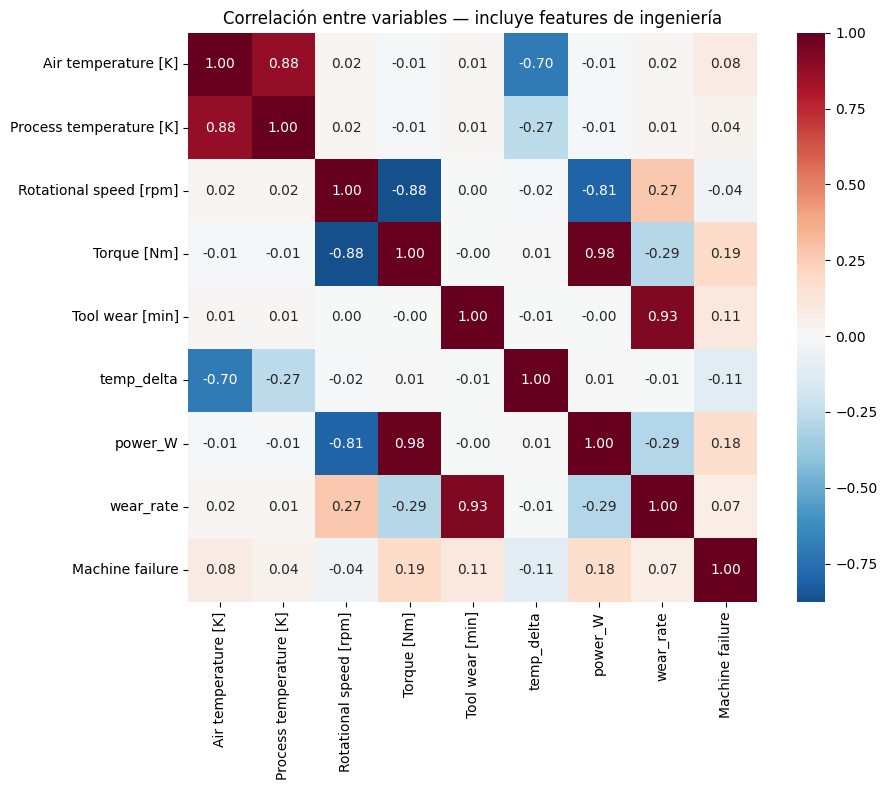

In [19]:
fig6 = plot_correlation_heatmap(df)
plt.show()

**Interpretación — Correlación:**

La correlación Torque ↔ RPM = -0.88 confirma operación a potencia aproximadamente constante (P = τ × ω), validando power_W como feature representativa del régimen operativo. wear_rate presenta alta colinealidad con Tool wear [min] (r=0.93), lo que indica dominancia de la variable acumulada sobre la normalización por potencia. Ninguna variable individual supera r=0.20 con Machine failure, indicando que el fallo es un fenómeno multivariante no lineal — argumento para modelos basados en árboles en la fase de modelado.

> **Referencia:** Fig. 6 — plot_correlation_heatmap( )

---

## 8. Conclusiones

### Conclusión 1 — Distribución de fallos y desbalanceo de clase
*(Fig. 1 — plot_failure_distribution)*

El dataset presenta una tasa global de fallo del **3.39%** (339 de 10.000 registros),con distribución fuertemente desbalanceada. El mecanismo de fallo más frecuente es **HDF** (Heat Dissipation Failure) con **115 casos** (33.9% de todos los fallos), seguido de OSF (98) y PWF (95). El fallo menos frecuente es RNF (19 casos, 0.19%), consistente con su naturaleza estocástica: al no estar asociado a ningún mecanismo de degradación determinista, se descartará en la fase de modelado supervisado. El desbalanceo 96.6/3.4 exigirá estrategias de compensación (SMOTE o class_weight) en el clasificador.

### Conclusión 2 — Predictores principales identificados por tipo de fallo
*(Fig. 2 — plot_temp_delta_by_failure | Fig. 3 — plot_torque_speed_scatter | Fig. 4 — plot_wear_vs_twf)*

Cada tipo de fallo responde a un predictor dominante diferente:

- **HDF:** temp_delta discrimina con separación clara entre grupos. La mediana  en operación normal es 9.8 K frente a 8.3 K en fallos HDF — una reducción de **1.5 K** que refleja el calentamiento del aire cuando falla la disipación. La varianza del grupo HDF=1 es mínima (std=0.28 K), lo que sugiere un umbral de activación próximo a 8.5 K.

- **PWF/OSF:** La zona de peligro en el espacio torque×velocidad se localiza en **1.200–1.400 rpm con torque >60 Nm**. Los fallos presentan una power_W media de **7.283 W** frente a **6.245 W** en operación normal (+16.6%). La correlación Torque↔RPM = **-0.88** confirma operación a potencia aproximadamente constante, validando power_W (P = τ × ω) como feature representativa del régimen operativo.

- **TWF:** Tool wear [min] predice TWF con separación casi perfecta. El **100%** de los fallos TWF ocurre con desgaste acumulado **>198 min** (mediana=214.5 min, RIC <20 min), mientras el 75% de la operación normal se mantiene por debajo de 162 min. El patrón indica un umbral de activación determinista, no una degradación gradual.

### Conclusión 3 — Efecto del tipo de producto sobre la tasa de fallos
*(Fig. 5a — plot_failure_rate_by_type | Fig. 5b — plot_wear_by_product_type)*

La tasa de fallo decrece de forma monotónica con la calidad del producto:
**L = 3.92%**, **M = 2.77%**, **H = 2.09%** — el tipo L falla **1.88x** más que el tipo H. Sin embargo, el perfil de desgaste acumulado es prácticamente idéntico entre los tres tipos (distribución uniforme 0–210 min en los tres grupos), lo que descarta que la mayor tasa de L sea un artefacto del tiempo de operación. La diferencia es intrínseca a las tolerancias de fabricación y condiciones de proceso
asignadas a cada calidad. Type tiene valor predictivo para el clasificador multiclase y es independiente de Tool wear [min].

---

## Próximos pasos

- **Creación de Feature avanzado:** interacciones entre variables, codificación ordinal de Type, normalización para modelos lineales.
- **Modelado:** clasificación multiclase del tipo de fallo (Random Forest / XGBoost) y predicción de RUL (Remaining Useful Life).
- **Explicabilidad:** SHAP values para auditar las decisiones del modelo en contexto industrial.
- **Despliegue:** API FastAPI + Docker para consumir el modelo en tiempo real.